In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor   

print("All libraries loaded successfully")

All libraries loaded successfully


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Features and target
X = df.drop('medv', axis=1)
y = df['medv']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

# Train both models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

# Compare performance
print("----- Model Comparison -----")

print("Linear Regression:")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\nRandom Forest:")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))

----- Model Comparison -----
Linear Regression:
R2 Score: 0.6687594935356317
MAE: 3.1890919658878416

Random Forest:
R2 Score: 0.8925431501835708
MAE: 2.0367352941176473


In [7]:
# Use the best model (Random Forest)
y_pred = rf.predict(X_test)

print("Predictions:", y_pred[:5])
print("Actual:", y_test.values[:5])

Predictions: [22.89  30.694 16.342 23.528 16.796]
Actual: [23.6 32.4 13.6 22.8 16.1]


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

# Use Random Forest predictions
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 7.88021732352941
R2 Score: 0.8925431501835708


In [9]:
import pandas as pd

# Get feature importance from Random Forest
importance = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

    Feature  Importance
5        rm    0.504274
12    lstat    0.309532
7       dis    0.059881
0      crim    0.037635
10  ptratio    0.016242
9       tax    0.016142
4       nox    0.014987
6       age    0.013845
11        b    0.012754
2     indus    0.007742
8       rad    0.004200
1        zn    0.001652
3      chas    0.001113


In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Train Decision Tree model
model2 = DecisionTreeRegressor(random_state=42)
model2.fit(X_train, y_train)

# Predictions
y_pred2 = model2.predict(X_test)

# Evaluation
r2_dt = r2_score(y_test, y_pred2)
print("Decision Tree R2:", r2_dt)

Decision Tree R2: 0.7570616506127126


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale AFTER split
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# train
model = LinearRegression()
model.fit(X_train_s, y_train)

# predict
y_pred = model.predict(X_test_s)

print("Correct Scaled R2:", r2_score(y_test, y_pred))

Correct Scaled R2: 0.668759493535632


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# split (same as before to preserve result)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train Random Forest (NO SCALING)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# evaluation
rf_r2 = r2_score(y_test, y_pred_rf)
print("Random Forest R2:", rf_r2)

Random Forest R2: 0.8925431501835708


In [15]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.87666414 0.86417037 0.81429827 0.91309573 0.88700642]
Average CV score: 0.8710469836198417


In [16]:
from sklearn.model_selection import KFold, cross_val_score

# Define K-Fold with shuffling
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on Random Forest model
scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

# Print results
print("Shuffled CV Scores:", scores)
print("Average CV Score:", scores.mean())

Shuffled CV Scores: [0.87666414 0.86417037 0.81429827 0.91309573 0.88700642]
Average CV Score: 0.8710469836198417


Model saved successfully!


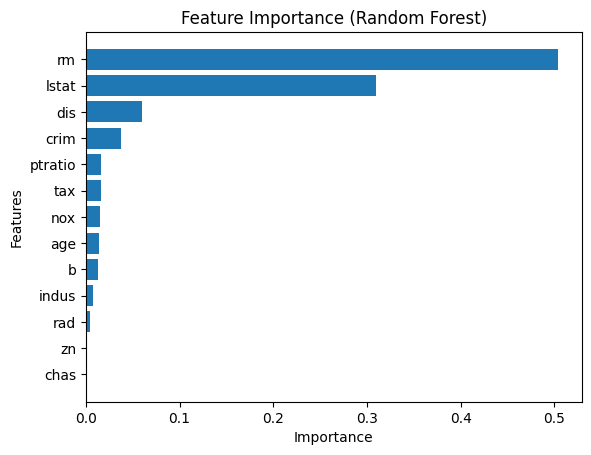

In [18]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Save model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

# --- Feature Importance ---

# Get feature importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()